In [59]:
import pandas as pd
from matplotlib import pyplot as plt
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

data_passenger = pd.read_csv('../Titanic-Dataset.csv')

In [60]:
# Load the two Titanic datasets
train = pd.read_csv("../train.csv")
test = pd.read_csv("../test.csv")

# Mark which dataset each row came from
train["is_train"] = 1
test["is_train"] = 0

# Combine them temporarily for preprocessing
combined = pd.concat([train, test], ignore_index=True)

# Fill missing values
combined["Age"] = combined["Age"].fillna(combined["Age"].median())
combined["Fare"] = combined["Fare"].fillna(combined["Fare"].median())
combined["Embarked"] = combined["Embarked"].fillna(
    combined["Embarked"].mode()[0]
)

# Convert Sex into numbers
combined["Sex"] = combined["Sex"].map({
    "male": 0,
    "female": 1
})

# Convert Embarked into numerical columns
combined = pd.get_dummies(
    combined,
    columns=["Embarked"],
    drop_first=True
)

# Separate the data again
train_processed = combined[combined["is_train"] == 1].copy()
test_processed = combined[combined["is_train"] == 0].copy()

# Check that everything worked
print("Train shape:", train_processed.shape)
print("Test shape:", test_processed.shape)

Train shape: (891, 14)
Test shape: (418, 14)


In [61]:
features = [
    "Pclass",
    "Sex",
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "Embarked_Q",
    "Embarked_S"
]

X = train_processed[features]
y = train_processed["Survived"]
X_test = test_processed[features]

print("X:", X.shape)
print("y:", y.shape)
print("X_test:", X_test.shape)

X: (891, 8)
y: (891,)
X_test: (418, 8)


In [62]:
from sklearn.model_selection import train_test_split

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_valid:", X_valid.shape)
print("y_train:", y_train.shape)
print("y_valid:", y_valid.shape)

X_train: (712, 8)
X_valid: (179, 8)
y_train: (712,)
y_valid: (179,)


In [63]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=300,
    max_depth=6,
    random_state=42
)

In [64]:
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",6
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap:

In [65]:
y_pred = model.predict(X_valid)

In [66]:
print(y_pred[:20])

[0. 0. 0. 0. 1. 0. 1. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]


In [67]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_valid, y_pred)

print("Validation accuracy:", accuracy)

Validation accuracy: 0.8044692737430168


In [68]:
from sklearn.metrics import classification_report

print(classification_report(y_valid, y_pred))

              precision    recall  f1-score   support

         0.0       0.80      0.92      0.85       110
         1.0       0.83      0.62      0.71        69

    accuracy                           0.80       179
   macro avg       0.81      0.77      0.78       179
weighted avg       0.81      0.80      0.80       179



In [69]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_valid, y_pred)

print("Validation accuracy:", accuracy)

Validation accuracy: 0.8044692737430168


Making improvements

In [70]:
# combined["Title"] = combined["Name"].str.extract(
#     r",\s*([^.]*)\."
# )[0]

In [71]:
def get_title(name):
    parts = name.split(",")
    title_part = parts[1]
    title = title_part.split(".")[0]
    return title.strip()

In [72]:
combined["Title"] = combined["Name"].apply(get_title)

In [73]:
print(combined["Title"].value_counts())

Title
Mr              757
Miss            260
Mrs             197
Master           61
Rev               8
Dr                8
Col               4
Ms                2
Major             2
Mlle              2
Don               1
Mme               1
Lady              1
Sir               1
Capt              1
the Countess      1
Jonkheer          1
Dona              1
Name: count, dtype: int64


In [74]:
common_titles = ["Mr", "Miss", "Mrs", "Master"]

combined["Title"] = combined["Title"].where(
    combined["Title"].isin(common_titles),
    "Rare"
)

In [75]:
print(combined["Title"].value_counts())

Title
Mr        757
Miss      260
Mrs       197
Master     61
Rare       34
Name: count, dtype: int64


In [76]:
combined = pd.get_dummies(
    combined,
    columns=["Title"],
    drop_first=True
)

In [77]:
print(combined.columns.tolist())

['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'is_train', 'Embarked_Q', 'Embarked_S', 'Title_Miss', 'Title_Mr', 'Title_Mrs', 'Title_Rare']


In [78]:
combined["FamilySize"] = (
    combined["SibSp"] +
    combined["Parch"] +
    1
)

In [79]:
combined["IsAlone"] = (
    combined["FamilySize"] == 1
).astype(int)

In [80]:
train_processed = combined[
    combined["is_train"] == 1
].copy()

test_processed = combined[
    combined["is_train"] == 0
].copy()

In [81]:
print("Train:", train_processed.shape)
print("Test:", test_processed.shape)

Train: (891, 20)
Test: (418, 20)


In [82]:
features = [
    "Pclass",
    "Sex",
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "Embarked_Q",
    "Embarked_S",
    "FamilySize",
    "IsAlone",
    "Title_Miss",
    "Title_Mr",
    "Title_Mrs",
    "Title_Rare"
]

In [83]:
X = train_processed[features]

y = train_processed["Survived"]

X_test = test_processed[features]

In [84]:
print("X:", X.shape)
print("y:", y.shape)
print("X_test:", X_test.shape)

X: (891, 14)
y: (891,)
X_test: (418, 14)


In [85]:
print("X:", X.shape)
print("y:", y.shape)
print("X_test:", X_test.shape)

X: (891, 14)
y: (891,)
X_test: (418, 14)


In [86]:
from sklearn.model_selection import train_test_split

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training:", X_train.shape)
print("Validation:", X_valid.shape)

Training: (712, 14)
Validation: (179, 14)


In [87]:
from sklearn.ensemble import RandomForestClassifier

model_improved = RandomForestClassifier(
    n_estimators=500,
    max_depth=7,
    min_samples_leaf=2,
    random_state=42
)

In [88]:
model_improved.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",500
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",7
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap:

In [89]:
y_pred_improved = model_improved.predict(X_valid)

In [90]:
from sklearn.metrics import accuracy_score

accuracy_improved = accuracy_score(
    y_valid,
    y_pred_improved
)

print("Improved validation accuracy:", accuracy_improved)

Improved validation accuracy: 0.8268156424581006


In [91]:
final_model = RandomForestClassifier(
    n_estimators=500,
    max_depth=7,
    min_samples_leaf=2,
    random_state=42
)

final_model.fit(X, y)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",500
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",7
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap:

In [92]:
test_predictions = final_model.predict(X_test)

In [93]:
print(len(test_predictions))

418


In [94]:
print(test_predictions[:20])

[0. 0. 0. 0. 1. 0. 1. 0. 1. 0. 0. 0. 1. 0. 1. 1. 0. 0. 0. 1.]


In [95]:
print(set(test_predictions))

{np.float64(0.0), np.float64(1.0)}


In [96]:
submission = pd.DataFrame({
    "PassengerId": test["PassengerId"],
    "Survived": test_predictions.astype(int)
})

In [97]:
print(submission.head())

   PassengerId  Survived
0          892         0
1          893         0
2          894         0
3          895         0
4          896         1


In [98]:
print("Shape:", submission.shape)
print("Columns:", submission.columns.tolist())
print("Missing values:")
print(submission.isnull().sum())

Shape: (418, 2)
Columns: ['PassengerId', 'Survived']
Missing values:
PassengerId    0
Survived       0
dtype: int64


In [99]:
print(submission["Survived"].value_counts())

Survived
0    267
1    151
Name: count, dtype: int64


In [100]:
submission.to_csv("submission.csv", index=False)

In [101]:
import os

print(os.path.exists("submission.csv"))

True


In [102]:
print("Shape:", submission.shape)
print("Columns:", submission.columns.tolist())
print(submission.isnull().sum())

Shape: (418, 2)
Columns: ['PassengerId', 'Survived']
PassengerId    0
Survived       0
dtype: int64


In [103]:
submission.to_csv("submission.csv", index=False)

In [104]:
import os

print(os.path.exists("submission.csv"))

True


Now for the visuals

In [105]:
print("Train:", train.shape)
print("Test:", test.shape)
print("Processed train:", train_processed.shape)
print("Processed test:", test_processed.shape)

Train: (891, 13)
Test: (418, 12)
Processed train: (891, 20)
Processed test: (418, 20)


In [106]:
import pandas as pd

train = pd.read_csv("../train.csv")
test = pd.read_csv("../test.csv")

print("Train:", train.shape)
print("Test:", test.shape)

Train: (891, 12)
Test: (418, 11)


In [107]:
total_passengers = len(train)

survivors = train["Survived"].sum()

survival_rate = train["Survived"].mean() * 100

print("Total passengers:", total_passengers)
print("Survivors:", survivors)
print("Survival rate:", round(survival_rate, 2), "%")

Total passengers: 891
Survivors: 342
Survival rate: 38.38 %


In [108]:
total_passengers = len(train)

survivors = train["Survived"].sum()

survival_rate = train["Survived"].mean() * 100

print("Total passengers:", total_passengers)
print("Survivors:", survivors)
print("Survival rate:", round(survival_rate, 2), "%")

Total passengers: 891
Survivors: 342
Survival rate: 38.38 %


In [109]:
train["Survived"].mean()

np.float64(0.3838383838383838)

In [110]:
gender_survival = (
    train.groupby("Sex")["Survived"]
    .mean()
    .mul(100)
)

print(gender_survival)

Sex
female    74.203822
male      18.890815
Name: Survived, dtype: float64


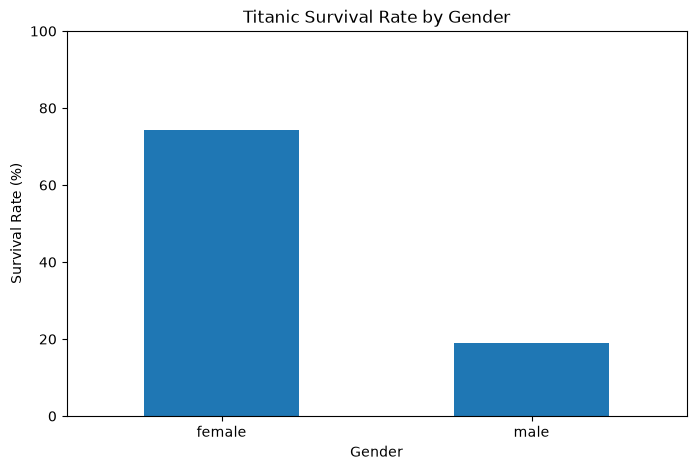

In [111]:
gender_survival.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Titanic Survival Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Survival Rate (%)")
plt.xticks(rotation=0)
plt.ylim(0, 100)

plt.show()

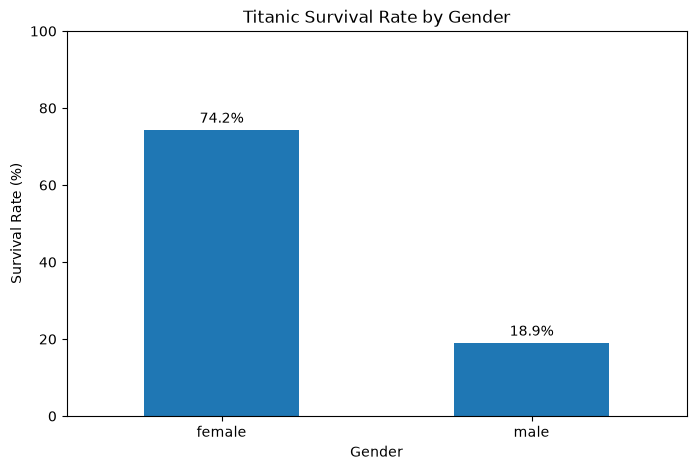

In [112]:
ax = gender_survival.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Titanic Survival Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Survival Rate (%)")
plt.xticks(rotation=0)
plt.ylim(0, 100)

for i, value in enumerate(gender_survival):
    ax.text(
        i,
        value + 2,
        f"{value:.1f}%",
        ha="center"
    )

plt.show()